# Vegan Meat on Q-Commerce — Bottom-Up Market Sizing

> *"The vegan meat category on Indian quick commerce is a real but narrow opportunity — addressable GMV of ~₹627 Cr in 2024, growing to ~₹2,500 Cr by 2027. It will not become mass market. Two or three focused brands will be profitable. Most others will exit before 2027. Winning requires brutal prioritization on price, taste, and channel placement — not brand storytelling."*

---

**Question:** What is the realistic addressable GMV for vegan/plant-based meat on Indian quick commerce platforms?

**Why bottom-up?** Most analysts size this market top-down using India vegan food projections. That overstates it. The right entry point is the q-commerce buyer who is health-motivated — not the ideological vegan. The total vegan market and the q-comm vegan meat buyer are entirely different populations.

**Method:** Buyer funnel → purchase behaviour → GMV model → competitive context → so-what.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


## Part 1 — Defining the Buyer

The q-comm vegan meat buyer is **not** the ethical vegan (8 million self-identified vegans in India, most not on q-comm).

It is the **health-motivated flexitarian**: 25–35 year-old urban professional, gym-going, protein-tracking, consciously reducing meat — not for ethics but for health.

- 67% of Indian consumers report actively trying to eat healthy *(Statista, 2024)*
- 43% of millennials report higher spend on health products
- Q-comm skews younger, urban, affluent — a structural match for this buyer profile

In [2]:
# === BUYER FUNNEL — all figures from first-principles + public data ===

funnel = {
    'Urban India Internet Users': {
        'population': 480_000_000,
        'filter_pct': None,
        'rationale': 'Urban pop 523M × smartphone penetration 77% (India Briefing, 2024)'
    },
    'Active Q-Comm Buyers': {
        'population': 75_000_000,
        'filter_pct': 0.156,
        'rationale': '~16% of urban internet users; derived from combined daily orders (Blinkit 6L + Zepto 3L + Instamart 5L = 14L/day → ~75M monthly active buyers)'
    },
    'Health-Motivated (Protein / Fitness Focus)': {
        'population': 22_000_000,
        'filter_pct': 0.293,
        'rationale': '~29% of active q-comm buyers; conservative given 67% national health-eating intent but q-comm skews younger/urban'
    },
    'Open to Plant-Based Meat': {
        'population': 7_500_000,
        'filter_pct': 0.341,
        'rationale': '~34% of health-focused; consistent with global flexitarian trial data'
    },
    'Addressable Buyer Pool (2024)': {
        'population': 2_800_000,
        'filter_pct': 0.373,
        'rationale': '~37% of open pool convert to actual purchase consideration — conservative given price barrier and limited SKU availability'
    }
}

print(f'BUYER FUNNEL\n{"="*70}')
prev = None
for stage, data in funnel.items():
    pop = data['population']
    if prev:
        drop = f"({data['filter_pct']*100:.0f}% of previous stage)"
    else:
        drop = '(starting point)'
    print(f"\n{stage}")
    print(f"  Population: {pop/1e6:.1f}M  {drop}")
    print(f"  Rationale:  {data['rationale']}")
    prev = pop

BUYER FUNNEL

Urban India Internet Users
  Population: 480.0M  (starting point)
  Rationale:  Urban pop 523M × smartphone penetration 77% (India Briefing, 2024)

Active Q-Comm Buyers
  Population: 75.0M  (16% of previous stage)
  Rationale:  ~16% of urban internet users; derived from combined daily orders (Blinkit 6L + Zepto 3L + Instamart 5L = 14L/day → ~75M monthly active buyers)

Health-Motivated (Protein / Fitness Focus)
  Population: 22.0M  (29% of previous stage)
  Rationale:  ~29% of active q-comm buyers; conservative given 67% national health-eating intent but q-comm skews younger/urban

Open to Plant-Based Meat
  Population: 7.5M  (34% of previous stage)
  Rationale:  ~34% of health-focused; consistent with global flexitarian trial data

Addressable Buyer Pool (2024)
  Population: 2.8M  (37% of previous stage)
  Rationale:  ~37% of open pool convert to actual purchase consideration — conservative given price barrier and limited SKU availability


## Part 2 — GMV Model (2024–2027)

The addressable buyer pool grows not because veganism is exploding, but because **q-commerce itself is expanding** — Tier-2 city dark store rollout and rising platform density make the category more discoverable year-on-year.

In [3]:
# === GMV PROJECTION TABLE ===

gmv_data = {
    'Year': [2024, 2025, 2026, 2027],
    'Buyer Pool (M)': [2.8, 3.9, 5.2, 6.8],
    'Avg Orders/Buyer/Year': [8, 9, 10, 11],
    'Avg Order Value (₹)': [280, 295, 315, 335],
}

df = pd.DataFrame(gmv_data)
df['Addressable GMV (₹ Cr)'] = (
    df['Buyer Pool (M)'] * 1e6 *
    df['Avg Orders/Buyer/Year'] *
    df['Avg Order Value (₹)'] / 1e7
).round(0).astype(int)

print('GMV MODEL — Vegan Meat on Q-Commerce\n')
print(df.to_string(index=False))
print(f'\nNote: This is ADDRESSABLE GMV — the theoretical ceiling.')
print(f'Realized GMV will be 30-50% lower given structural distribution challenges.')

GMV MODEL — Vegan Meat on Q-Commerce

 Year  Buyer Pool (M)  Avg Orders/Buyer/Year  Avg Order Value (₹)  Addressable GMV (₹ Cr)
 2024             2.8                      8                  280                     627
 2025             3.9                      9                  295                    1035
 2026             5.2                     10                  315                    1638
 2027             6.8                     11                  335                    2506

Note: This is ADDRESSABLE GMV — the theoretical ceiling.
Realized GMV will be 30-50% lower given structural distribution challenges.


In [4]:
# === CONTEXT: HOW BIG IS THIS RELATIVE TO TOTAL Q-COMM? ===

india_qcomm_gmv_cr = 54000  # ~$6.5B = ₹54,000 Cr total q-comm GMV
vegan_2024 = 627
share = vegan_2024 / india_qcomm_gmv_cr * 100

print(f'India Total Q-Comm GMV:         ₹{india_qcomm_gmv_cr:,} Cr')
print(f'Vegan Meat Addressable GMV 2024: ₹{vegan_2024} Cr')
print(f'Category share of q-comm:        {share:.1f}% — a rounding error on platform P&Ls')
print(f'\nPlatforms will carry it as a health-halo signal, not a volume driver.')
print(f'They will NOT push it unless sell-through justifies shelf space.')

India Total Q-Comm GMV:         ₹54,000 Cr
Vegan Meat Addressable GMV 2024: ₹627 Cr
Category share of q-comm:        1.2% — a rounding error on platform P&Ls

Platforms will carry it as a health-halo signal, not a volume driver.
They will NOT push it unless sell-through justifies shelf space.


## Part 3 — Platform Distribution Reality

Getting listed on Blinkit is not getting distributed. This is the most underestimated structural challenge for vegan meat brands.

**Key dynamics:**
- Each dark store carries 2,000–8,000 SKUs — niche categories compete for limited "High Protein" / "Health & Wellness" slots
- Platform commission: 18–25% of GMV + listing fees for premium placement (₹56–70 on a ₹280 order goes to platform)
- Blinkit AOV trend: ₹250 (2021) → ₹625 (Q2 2024) → ₹709 estimated (2026) — **premiumisation tailwind** for health SKUs
- Sell-through threshold: SKUs not moving 60–70% of stock per replenishment cycle get delisted
- Brands cracking Blinkit's "High Protein" section achieve 3–4x visibility vs standard search — not automatic

**Q-comm platform data is the category's most valuable asset.** Real-time sell-through by pin code tells brands exactly which neighbourhoods convert — enabling hyper-targeted production before scaling manufacturing.

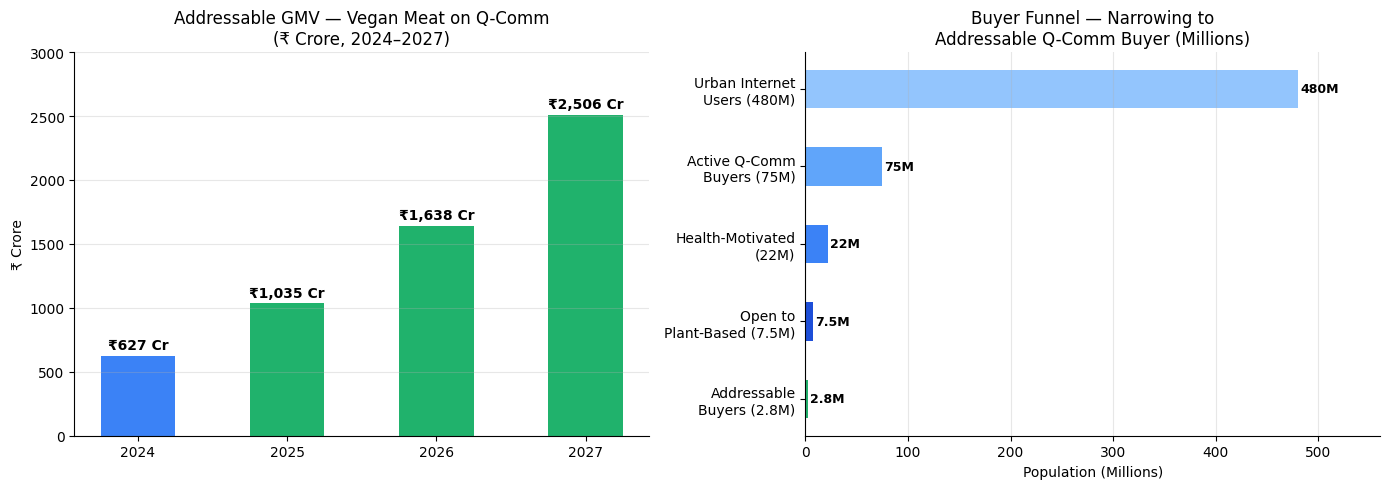

Chart saved to outputs/market_sizing_charts.png


In [5]:
# === VISUALISE GMV GROWTH + BUYER POOL ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — GMV growth
ax1 = axes[0]
bars = ax1.bar(df['Year'].astype(str), df['Addressable GMV (₹ Cr)'],
               color=['#3b82f6', '#20b26c', '#20b26c', '#20b26c'], width=0.5)
for bar, val in zip(bars, df['Addressable GMV (₹ Cr)']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'₹{val:,} Cr', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_title('Addressable GMV — Vegan Meat on Q-Comm\n(₹ Crore, 2024–2027)', fontsize=12)
ax1.set_ylabel('₹ Crore')
ax1.set_ylim(0, 3000)
ax1.grid(axis='y', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Chart 2 — Buyer funnel waterfall
ax2 = axes[1]
stages = ['Urban Internet\nUsers (480M)', 'Active Q-Comm\nBuyers (75M)',
          'Health-Motivated\n(22M)', 'Open to\nPlant-Based (7.5M)',
          'Addressable\nBuyers (2.8M)']
pops = [480, 75, 22, 7.5, 2.8]
colors = ['#93c5fd', '#60a5fa', '#3b82f6', '#1d4ed8', '#20b26c']
bars2 = ax2.barh(stages, pops, color=colors, height=0.5)
for bar, val in zip(bars2, pops):
    ax2.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
             f'{val}M', va='center', fontsize=9, fontweight='bold')
ax2.set_title('Buyer Funnel — Narrowing to\nAddressable Q-Comm Buyer (Millions)', fontsize=12)
ax2.set_xlabel('Population (Millions)')
ax2.set_xlim(0, 560)
ax2.grid(axis='x', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/market_sizing_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to outputs/market_sizing_charts.png')

## Part 4 — Competitive Landscape

India's vegan meat market ($78.6M plant-based meat, 2023) is fragmented with no clear dominant brand on q-commerce — a window that is open but narrowing.

In [6]:
# === COMPETITIVE LANDSCAPE TABLE ===

competitive = pd.DataFrame([
    {'Brand': 'Good Dot', 'Key Strength': 'Shelf-stable, lowest price, profitable',
     'Q-Comm Positioning': 'Widest accessible SKUs, strong retail proof of demand',
     '3-Year Verdict': 'LIKELY WINNER'},
    {'Brand': 'Wakao Foods', 'Key Strength': 'Jackfruit differentiation, strong D2C brand',
     'Q-Comm Positioning': 'D2C-first; needs deliberate platform push',
     '3-Year Verdict': 'POTENTIAL WINNER (if price improves)'},
    {'Brand': 'Blue Tribe', 'Key Strength': 'Celebrity backing (Kohli, Sharma), broad range',
     'Q-Comm Positioning': 'Premium price limits repeat purchase; marketing-heavy',
     '3-Year Verdict': 'HIGH RISK — brand before PMF'},
    {'Brand': 'ITC Incredible', 'Key Strength': 'Distribution scale, manufacturing, balance sheet',
     'Q-Comm Positioning': 'Can force placement; lacks brand identity in category',
     '3-Year Verdict': 'SLEEPER — if they prioritise it'},
    {'Brand': 'Imagine Meats', 'Key Strength': 'Celebrity (Riteish-Genelia), ADM partnership, taste',
     'Q-Comm Positioning': 'Premium, limited SKUs, foodservice-heavy; low q-comm intent',
     '3-Year Verdict': 'NICHE SURVIVOR'},
    {'Brand': 'Beyond Meat', 'Key Strength': 'Global brand equity, product quality',
     'Q-Comm Positioning': '3–5x price of local alternatives; only Nature Basket-level reach',
     '3-Year Verdict': 'EXITS OR STAYS TINY'},
])

print('COMPETITIVE LANDSCAPE — Vegan Meat Q-Commerce India\n')
for _, row in competitive.iterrows():
    print(f"{row['Brand']:20} → {row['3-Year Verdict']}")
    print(f"  Strength: {row['Key Strength']}")
    print(f"  Q-Comm:   {row['Q-Comm Positioning']}\n")

COMPETITIVE LANDSCAPE — Vegan Meat Q-Commerce India

Good Dot             → LIKELY WINNER
  Strength: Shelf-stable, lowest price, profitable
  Q-Comm:   Widest accessible SKUs, strong retail proof of demand

Wakao Foods          → POTENTIAL WINNER (if price improves)
  Strength: Jackfruit differentiation, strong D2C brand
  Q-Comm:   D2C-first; needs deliberate platform push

Blue Tribe           → HIGH RISK — brand before PMF
  Strength: Celebrity backing (Kohli, Sharma), broad range
  Q-Comm:   Premium price limits repeat purchase; marketing-heavy

ITC Incredible       → SLEEPER — if they prioritise it
  Strength: Distribution scale, manufacturing, balance sheet
  Q-Comm:   Can force placement; lacks brand identity in category

Imagine Meats        → NICHE SURVIVOR
  Strength: Celebrity (Riteish-Genelia), ADM partnership, taste
  Q-Comm:   Premium, limited SKUs, foodservice-heavy; low q-comm intent

Beyond Meat          → EXITS OR STAYS TINY
  Strength: Global brand equity, product q

## Part 5 — The So-What

**The number isn't the point. The business logic is.**

In [7]:
# === MARKET SHARE SCENARIOS AT 2024 TAM ===

base_tam = 627  # ₹ Crore, 2024 addressable GMV
realized_tam = base_tam * 0.60  # 30-50% haircut for realized vs addressable

scenarios = [0.005, 0.01, 0.03, 0.05, 0.10]
labels = ['0.5%', '1%', '3%', '5%', '10%']

print(f'Addressable GMV 2024:          ₹{base_tam} Cr')
print(f'Realistic Realized GMV (~60%): ₹{realized_tam:.0f} Cr')
print(f'\n{"Market Share":<15} {"Addressable GMV Capture":<25} {"Realized GMV Capture"}')
print('-'*60)
for label, share in zip(labels, scenarios):
    a = base_tam * share
    r = realized_tam * share
    print(f'{label:<15} ₹{a:.1f} Cr{"":>15} ₹{r:.1f} Cr')

print(f'\nKey insight: A brand needs ~5% market share of addressable GMV')
print(f'to reach ₹30 Cr GMV — the minimum viable scale for a focused D2C brand.')

Addressable GMV 2024:          ₹627 Cr
Realistic Realized GMV (~60%): ₹376 Cr

Market Share    Addressable GMV Capture   Realized GMV Capture
------------------------------------------------------------
0.5%            ₹3.1 Cr                ₹1.9 Cr
1%              ₹6.3 Cr                ₹3.8 Cr
3%              ₹18.8 Cr                ₹11.3 Cr
5%              ₹31.4 Cr                ₹18.8 Cr
10%             ₹62.7 Cr                ₹37.6 Cr

Key insight: A brand needs ~5% market share of addressable GMV
to reach ₹30 Cr GMV — the minimum viable scale for a focused D2C brand.


In [8]:
# === WINNING CONDITIONS (summary) ===

print('WINNING CONDITIONS — What It Takes to Build a Profitable Brand\n')
print('1. ONE SKU FOCUS     — Chicken or keema alternative priced under ₹250')
print('   (not a full product range; category is too early for SKU proliferation)')
print()
print('2. TASTE FIRST       — Lead with "same protein, no cholesterol"')
print('   (NOT sustainability, NOT ethics — Indian consumers at scale do not act on these yet)')
print()
print('3. DATA AS R&D       — Use Blinkit/Zepto pin-code sell-through as R&D engine')
print('   (know which neighbourhoods convert before scaling manufacturing)')
print()
print('4. PRICE DISCIPLINE  — ASP under ₹280 for repeat; above ₹250 for unit economics')
print('   (The viable price window is narrow: ₹250-280 per order)')
print()
print('5. REPEAT > TRIAL    — Build for monthly re-order, not one-time sampling')
print('   (This TAM assumes 8 orders/year/buyer — the real risk is repeat purchase rate)')
print()
print('Best structural position today: Good Dot (price + distribution)')
print('Best brand equity today:        Wakao Foods')
print('Winner = whoever combines both by 2027.')

WINNING CONDITIONS — What It Takes to Build a Profitable Brand

1. ONE SKU FOCUS     — Chicken or keema alternative priced under ₹250
   (not a full product range; category is too early for SKU proliferation)

2. TASTE FIRST       — Lead with "same protein, no cholesterol"
   (NOT sustainability, NOT ethics — Indian consumers at scale do not act on these yet)

3. DATA AS R&D       — Use Blinkit/Zepto pin-code sell-through as R&D engine
   (know which neighbourhoods convert before scaling manufacturing)

4. PRICE DISCIPLINE  — ASP under ₹280 for repeat; above ₹250 for unit economics
   (The viable price window is narrow: ₹250-280 per order)

5. REPEAT > TRIAL    — Build for monthly re-order, not one-time sampling
   (This TAM assumes 8 orders/year/buyer — the real risk is repeat purchase rate)

Best structural position today: Good Dot (price + distribution)
Best brand equity today:        Wakao Foods
Winner = whoever combines both by 2027.


---

## Summary

| Metric | Value |
|---|---|
| Addressable GMV 2024 | ₹627 Cr |
| Addressable GMV 2027 | ₹2,506 Cr |
| Buyer pool 2024 | 2.8M households |
| Share of total Q-Comm GMV | ~1.2% |
| Key swing assumption | Buyer pool growth (q-comm expansion, not vegan adoption) |
| Primary risk | Repeat purchase rate — category is in trial phase, not habit formation |
| Minimum viable brand scale | ~₹30 Cr GMV = ~5% market share |

---

*Analysis by Shubham Singh. Built as a proof-of-work project demonstrating first-principles market sizing methodology.*  
*Sources: India Briefing (2024), Statista (2024), platform daily order volumes (public), IMARC vegan food market data.*